tensor([0.1667, 0.3333, 0.5000, 0.6667, 0.8333, 1.0000])


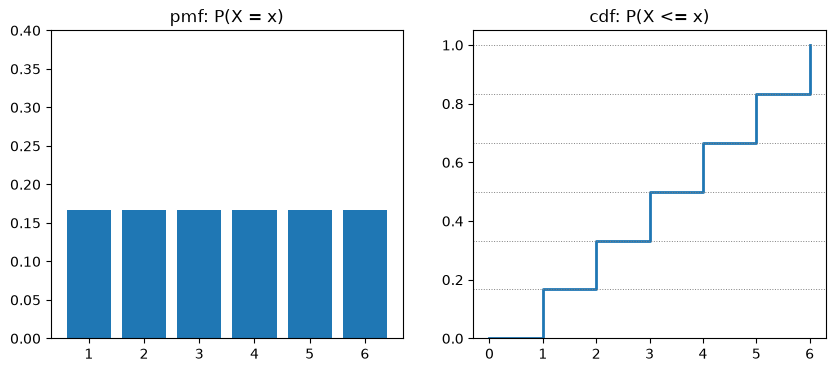

In [1]:
import torch
import matplotlib.pyplot as plt

faces = torch.arange(1, 7)
pmf = torch.full((6,), 1 / 6)
cdf = torch.cumsum(pmf, dim=0)  # [1/6, 2/6, ..., 1]
print(cdf)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(faces, pmf)
ax[0].set_title("pmf: P(X = x)")
ax[0].set_ylim(0, 0.4)

ax[1].step(
    torch.cat([torch.tensor([0]), faces]),
    torch.cat([torch.tensor([0.0]), cdf]),
    where="post",
    lw=2,
)
ax[1].set_title("cdf: P(X <= x)")
ax[1].set_ylim(0, 1.05)
for c in cdf:
    ax[1].axhline(c.item(), ls=":", lw=0.7, color="gray")
plt.show()


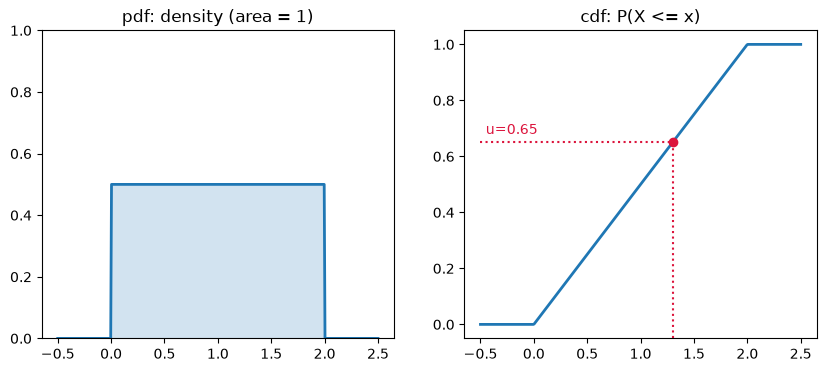

In [2]:
import torch
import matplotlib.pyplot as plt

a, b = 0.0, 2.0
x = torch.linspace(-0.5, 2.5, 400)

pdf = torch.where((x >= a) & (x <= b), torch.tensor(1 / (b - a)), torch.tensor(0.0))
cdf = ((x - a) / (b - a)).clamp(0, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(x, pdf, lw=2)
ax[0].fill_between(x, pdf, alpha=0.2)
ax[0].set_title("pdf: density (area = 1)")
ax[0].set_ylim(0, 1.0)

ax[1].plot(x, cdf, lw=2)
ax[1].set_title("cdf: P(X <= x)")
ax[1].set_ylim(-0.05, 1.05)

# read one sample off the ramp: u on the y-axis -> x on the x-axis
u = 0.65
ax[1].hlines(u, -0.5, a + u * (b - a), ls=":", color="crimson")
ax[1].vlines(a + u * (b - a), -0.05, u, ls=":", color="crimson")
ax[1].plot([a + u * (b - a)], [u], "o", color="crimson")
ax[1].text(-0.45, u + 0.03, f"u={u}", color="crimson")

plt.show()


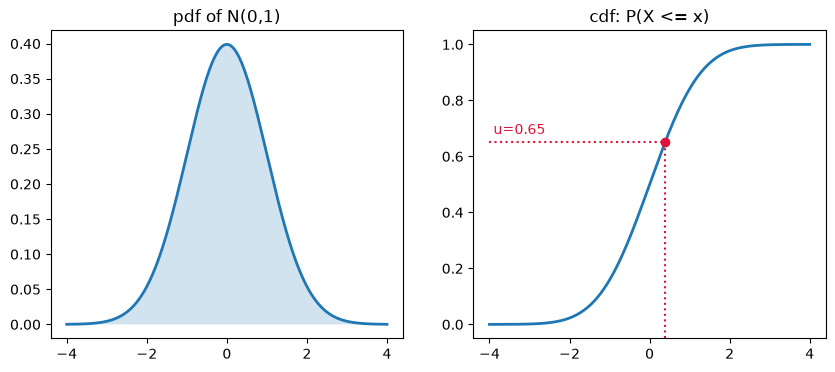

In [3]:
import torch, math
import matplotlib.pyplot as plt

x = torch.linspace(-4, 4, 500)
pdf = torch.exp(-(x**2) / 2) / math.sqrt(2 * math.pi)
cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x, pdf, lw=2)
ax[0].fill_between(x, pdf, alpha=0.2)
ax[0].set_title("pdf of N(0,1)")

ax[1].plot(x, cdf, lw=2)
ax[1].set_title("cdf: P(X <= x)")
ax[1].set_ylim(-0.05, 1.05)

u = 0.65
xu = math.sqrt(2) * torch.erfinv(torch.tensor(2 * u - 1))
ax[1].hlines(u, -4, xu, ls=":", color="crimson")
ax[1].vlines(xu, -0.05, u, ls=":", color="crimson")
ax[1].plot([xu], [u], "o", color="crimson")
ax[1].text(-3.9, u + 0.03, f"u={u}", color="crimson")
plt.show()
